<a href="https://colab.research.google.com/github/KishanKartha/Solving-OpenAI-CarRacing-v0/blob/main/Solving_OpenAI_CarRacing_v0_using_PID_controllers_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#!pip install gym pyvirtualdisplay > /dev/null 2>&1
#!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1

In [3]:
#!apt-get update > /dev/null 2>&1
#!apt-get install cmake > /dev/null 2>&1
#!pip install --upgrade setuptools 2>&1
#!pip install ez_setup > /dev/null 2>&1
#!pip install gym[box2d]
#!pip install Box2D gym
#!pip install moviepy

In [1]:
import gym
from gym.wrappers.record_video import RecordVideo
import glob
import io
import base64
from IPython.display import HTML
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from moviepy.editor import *

display = Display(visible=0, size=(1400, 900))
display.start()

"""
Utility functions to enable video recording of gym environment 
and displaying it.
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay 
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else: 
    print("Could not find video")
    

def wrap_env(env):
  env = RecordVideo(env, './video', name_prefix="test")
  return env

In [2]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

In [4]:
def pid(error,previous_error):
    Kp = 0.02
    Ki = 0.03
    Kd = 0.2   

    steering = Kp * error + Ki * (error + previous_error) + Kd * (error - previous_error)

    return steering

In [5]:
#import os
#fourcc = cv2.VideoWriter_fourcc(*'MJPG')
#os.system("rm output.avi")
#out = cv2.VideoWriter('output.avi', fourcc, 1.0, (96,96))

In [43]:
import gym

env = gym.make('CarRacing-v2')
#env = wrap_env(gym.make('CarRacing-v2', render_mode="rgb_array"))

observation, _ = env.reset()
#env.start_video_recorder()
env.render() 
rewardsum = 0  
previous_error = 0    

frames = []
frames.append(observation)
#out.write(observation[0])



#out.release()
print("reward", rewardsum)
#show_video()

reward 0


In [45]:
for i in range(100):
    action = (0,0,0)
    observation, reward, done, _, info = env.step(action)

In [49]:
class ImageProcessor:
    def __init__(self):
        pass
    
    def green_mask(self, observation):
        hsv = cv2.cvtColor(observation, cv2.COLOR_BGR2HSV)
        mask_green = cv2.inRange(hsv, (36, 25, 25), (70, 255,255))

        ## slice the green
        imask_green = mask_green>0
        green = np.zeros_like(observation, np.uint8)
        green[imask_green] = observation[imask_green]
        return(green)

    def gray_scale(self, observation):
        gray = cv2.cvtColor(observation, cv2.COLOR_RGB2GRAY)
        return gray

    def blur_image(self, observation):
        blur = cv2.GaussianBlur(observation, (5, 5), 0)
        return blur

    def canny_edge_detector(self, observation):
        canny = cv2.Canny(observation, 50, 150)
        return canny

    def find_error(self, observation, previous_error):
        cropped = observation[63:65, 24:73]

        green = self.green_mask(cropped)
        #grey  = self.gray_scale(green)
        #blur  = self.blur_image(grey)
        #canny = self.canny_edge_detector(blur)
        canny = self.canny_edge_detector(green)
        #find all non zero values in the cropped strip.
        #These non zero points(white pixels) corresponds to the edges of the road
        nz = cv2.findNonZero(canny)

        #horizontal cordinates of center of the road in the cropped slice
        mid  = 24

        # some further adjustments obtained through trail and error
        if nz[:,0,0].max() == nz[:,0,0].min():
            if nz[:,0,0].max() <30 and nz[:,0,0].max()>20:
                return previous_error
            if nz[:,0,0].max() >= mid:
                return(-15)
            else:
                return(+15)
        else:
            return(((nz[:,0,0].max() + nz[:,0,0].min())/2)-mid)

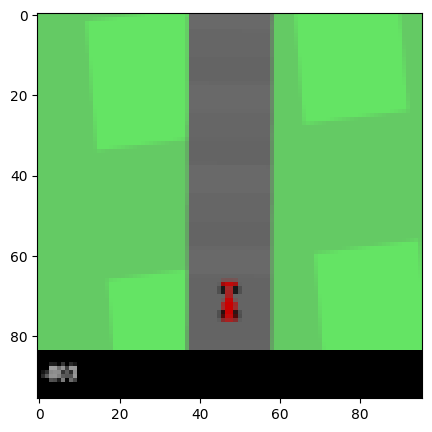

In [46]:
fig, (ax1) = plt.subplots(1, 1, figsize = (5,5))
ax1.imshow(observation)

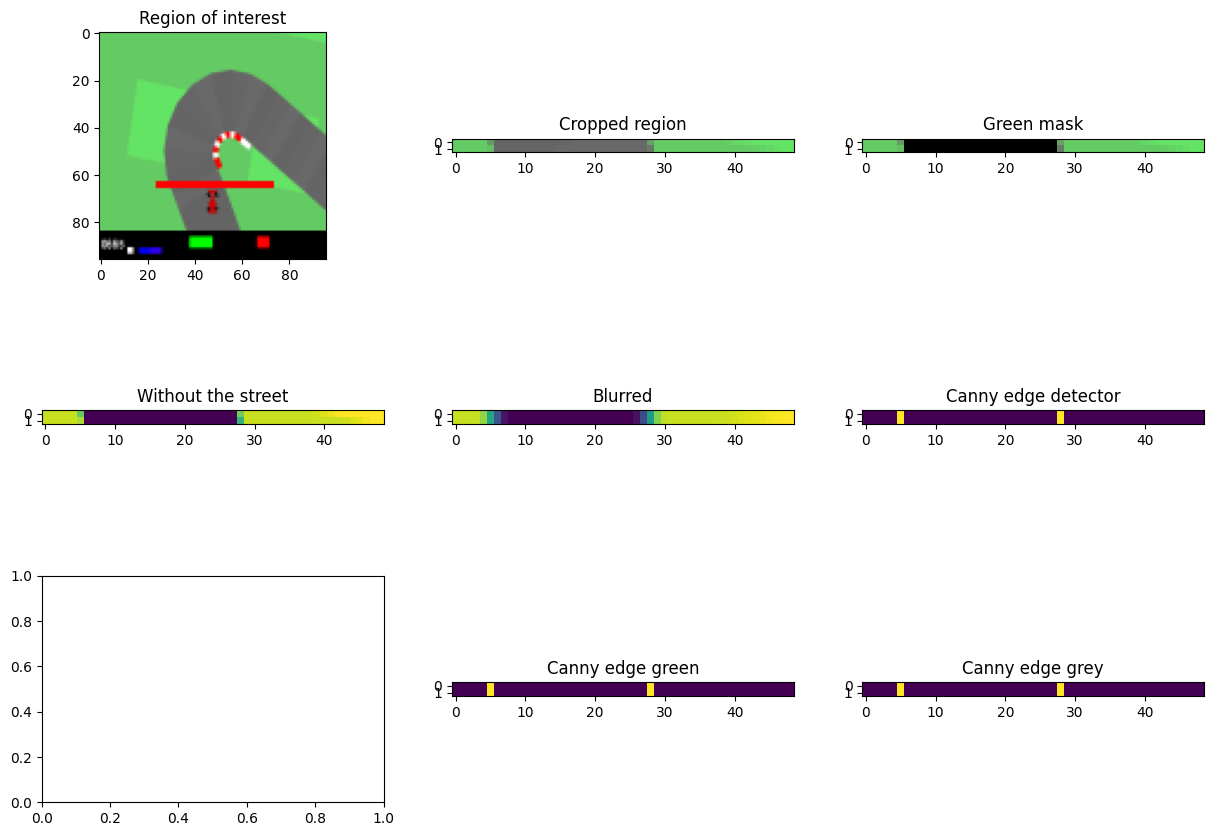

In [58]:
IP = ImageProcessor()
fig, ax = plt.subplots(3, 3, figsize = (15,10))

with_rectangle = cv2.rectangle(np.copy(observation), (24, 63), (73, 65), (255,0,0), -1)

cropped = observation[63:65, 24:73]

green = IP.green_mask(cropped)
grey  = IP.gray_scale(green)
blur  = IP.blur_image(grey)
canny = IP.canny_edge_detector(blur)
canny_green = IP.canny_edge_detector(green)
canny_grey = IP.canny_edge_detector(grey)

ax[0][0].set_title("Region of interest")
ax[0][0].imshow(with_rectangle)

ax[0][1].set_title("Cropped region")
ax[0][1].imshow(cropped)

ax[0][2].set_title("Green mask")
ax[0][2].imshow(green)

ax[1][0].set_title("Without the street")
ax[1][0].imshow(grey)

ax[1][1].set_title("Blurred")
ax[1][1].imshow(blur)

ax[1][2].set_title("Canny edge detector")
ax[1][2].imshow(canny)

ax[2][1].set_title("Canny edge green")
ax[2][1].imshow(canny_green)

ax[2][2].set_title("Canny edge grey")
ax[2][2].imshow(canny_grey)

In [54]:
nz = cv2.findNonZero(canny2)

#horizontal cordinates of center of the road in the cropped slice
mid  = 24

# some further adjustments obtained through trail and error
if nz[:,0,0].max() == nz[:,0,0].min():
    if nz[:,0,0].max() <30 and nz[:,0,0].max()>20:
        print("previous_error")
    if nz[:,0,0].max() >= mid:
        print(-15)
    else:
        print(+15)
else:
    print(((nz[:,0,0].max() + nz[:,0,0].min())/2)-mid)

-3.5


In [57]:
nz[:,0,0]

array([12, 13, 34,  7,  8,  9, 10, 11, 13, 34], dtype=int32)

In [51]:
IP.find_error(observation,0)

-3.5

In [52]:
errors_count = 0
for x in [1,0]*500:        
    try:
        error = IP.find_error(observation,previous_error)
    except:
        error = -15
        errors_count += 1
    pass

    steering = pid(error,previous_error)

    action = (steering,x,0)

    observation, reward, done, _, info = env.step(action)

    frames.append(observation)
    previous_error =error
    rewardsum = rewardsum +reward
    
    if done :
        env.close()
        break

print("Exceptions:", errors_count)

Exceptions: 0


In [13]:
clip = ImageSequenceClip(frames, fps=30)

In [11]:
os.system("export FFMPEG_BINARY=/usr/bin/ffmpeg")

0

In [14]:
clip.write_videofile("test.mp4",)

Moviepy - Building video test.mp4.
Moviepy - Writing video test.mp4



Moviepy - Done !
Moviepy - video ready test.mp4


In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize = (5,5))
ax1.imshow(observation)
